## Project Title: Analyzing Solar Imagery and Identifying Active Regions using Aditya-L1 Data
The image downloaded for the analysis is dated 09-05-2026 at 07:09:21 AM. The image is a level 1 image. 
The image is an off centered image of the sun which means that there are strong distortions in the western and southern hemispheres as mentioned in the PRADAN portal. 
The image is filtered by NB03 filter (central wavelength = 279.6 nm, bandpass = 0.4nm)

In [31]:
# Imports:

import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.io import fits
import sunpy.map 

from suitcolormap import suit_cmap, suit_norm
from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.measure import regionprops

In [32]:
# Loading the file: 

# we will now load the FITS file to the notebook and view the raw image: 
smap = sunpy.map.Map(r'D:\My Folder\ISA\Project work\Data\Raw\SUT_T26_0649_002132_Lev1.0_2026-05-09T07.09.21.400_08B2NB03.fits')

<Figure size 800x800 with 0 Axes>

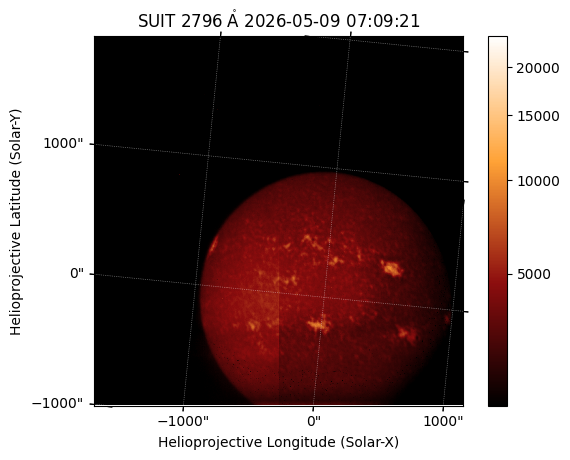

In [33]:
# Displaying Raw Image: 
cmap = suit_cmap('NB03')  # We have taken data from NB03 filter, hence we need to implement its color map.
plt.figure(figsize=(8,8))
smap.peek(cmap=cmap, vmin = 100, draw_grid= False)  
# We have taken a custom vmin value to ensure that we can differentiate sun from background.

NOTE: PRADAN portal warns- SUIT data taken in the off-centered position is highly distorted in the southern and western hemispheres. This needs to be taken into account for our analysis.

We have successfully imported the FITS file and displayed raw image in our notebook. We will now perform preprocessing of this image in order to convert this image from level 1 to level 2.  

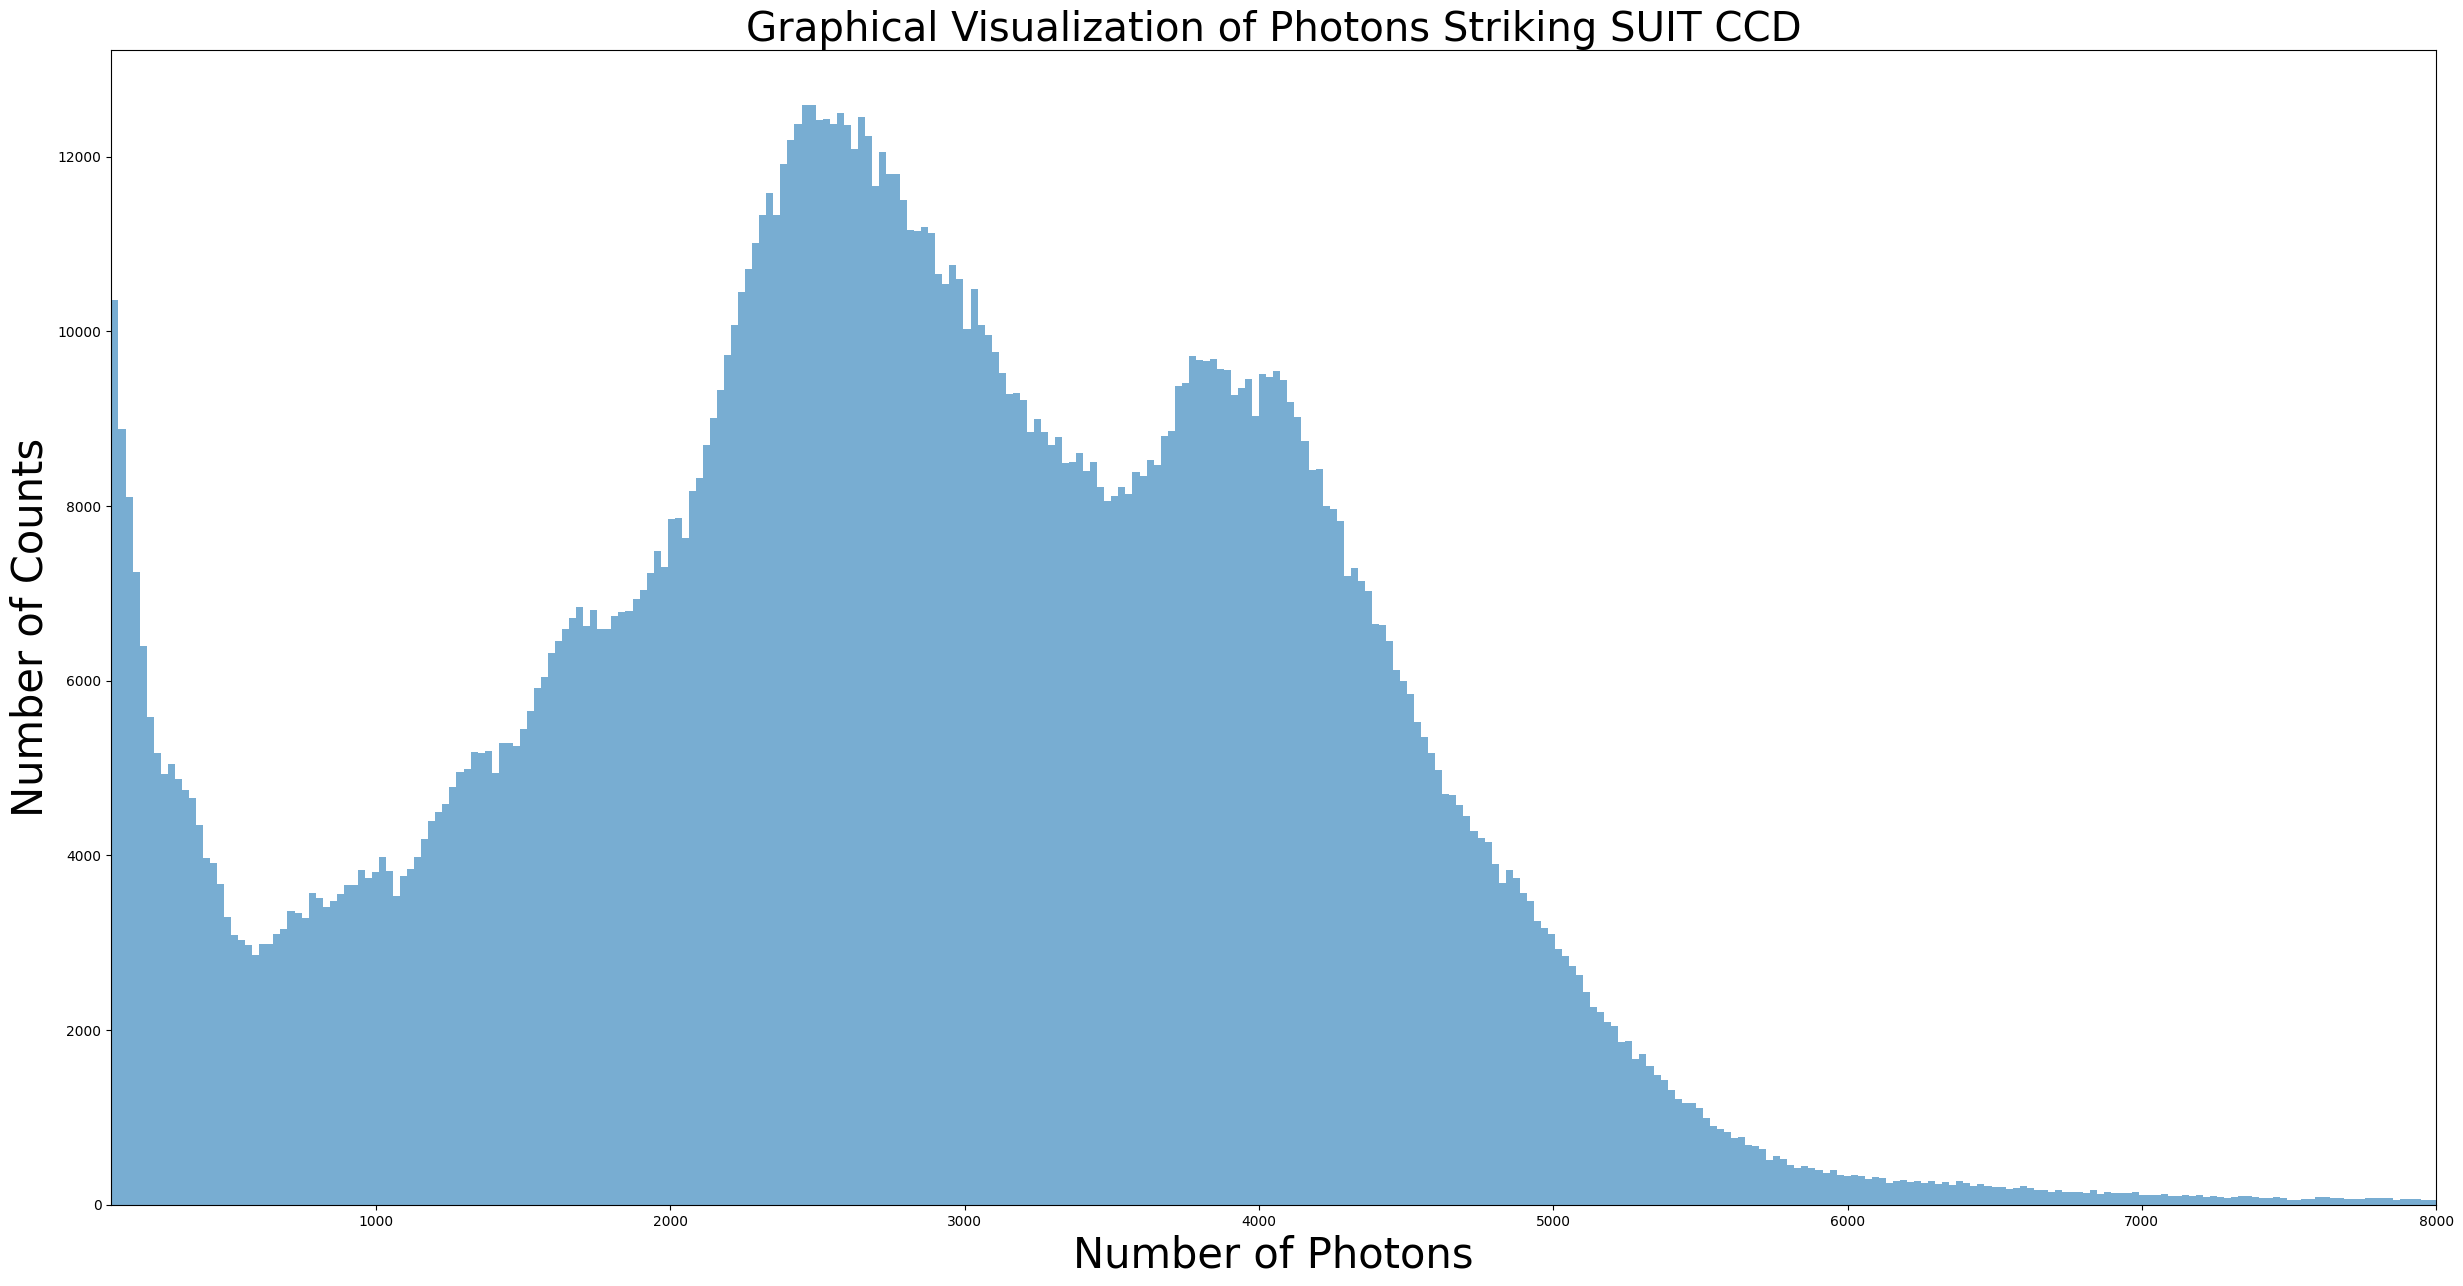

In [34]:
# Understanding histogram is necessary before performing preprocessing: 

arr_2d = smap.data     # 2048 x 2048 array
# arr_2d is the array in which each element  corresponds to photon count on each pixel of SUIT. 
arr_1d = arr_2d.flatten()
'''The array consists of many negative values which have no physical significance and so we have to remove them in
order to perform accurate analysis.'''
arr_1d[arr_1d<0]=0
arr_solar = arr_1d[arr_1d>100]
plt.figure(figsize=(30,15))
plt.hist(arr_solar, bins=1000, alpha=0.6)
plt.xlim(100,8000)
plt.xlabel('Number of Photons', fontsize= 30)
plt.ylabel('Number of Counts', fontsize=30)
plt.title('Graphical Visualization of Photons Striking SUIT CCD', fontsize = 29)
plt.show()

The following observations can be made form the histogram: 

1. We can see that two distinguishable peaks are formed in our graph. These peaks are of physical significance:
   a. The first peak corresponds to the quiet part of the sun that is the regions of sun except the active regions.
   b. The second peak corresponds to the solar limb or chromospheric limb. As can be seen from the graph it is brighter than the quiet sun but less brighter than active regions of the sun. 
2. The region of the graph corresponding to the active regions is the region after the second peak. Their count may be less but, they are brighter than rest of the sun. There is a reason why they are less in count, it i because they cover very less area of the sun's surface which can also be seen from our graph.     

In [35]:
# Flat-Field Correction: 
''' Flat-field correction is done to make for the errors which arise due to erroneous sensitivity of the pixels
which leads to artificial counts. It smoothens the abrupt rises and falls in the plot and only keeps the smooth
variations. 
This is done by applying uniform filter. Each output pixel is the average of all pixels in the neighborhood. 
'''

arr_2d[arr_2d<0] = 0
flat_field = uniform_filter(arr_2d, size=100)
'''We have selected size=100 as it not compromising the spatial details of detector and also gives us a valid enough flat field to work with.'''
# Applying correction: 

flat_field[flat_field<1]=1 # This is being done to prevent the division of arr_2d from 0 as flat_field contains many 0 values.
arr_ffc = arr_2d/flat_field * np.median(flat_field[flat_field>1])


I have applied flat field correction to our image and now we will plot the image to see what has flat field correction has done to our image.

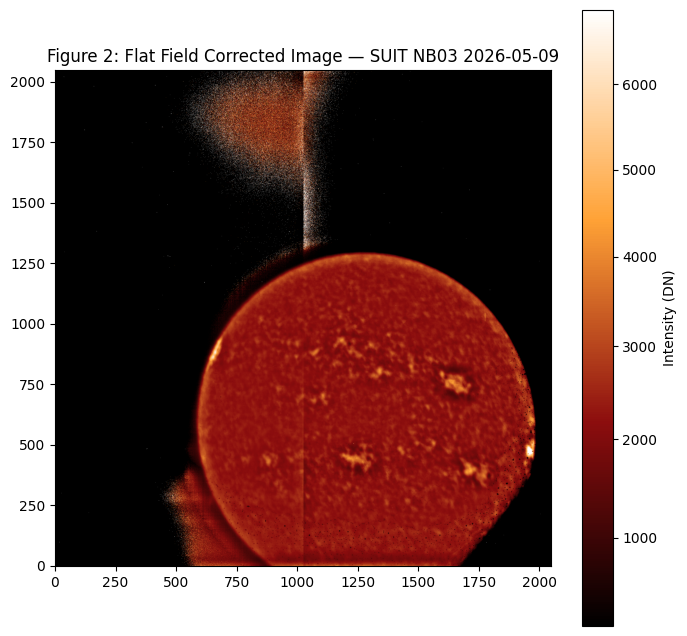

In [36]:
# Displaying Flat Field Corrected image: 
'''We will have to convert the ffc array to an image, we will use 'imshow' function for it.'''
cmap = suit_cmap('NB03')
norm = suit_norm(arr_ffc, 'NB03')
#plt.imshow(arr_ffc , cmap = cmap, vmin=np.percentile(arr_ffc,1), vmax=np.percentile(arr_ffc,99))
plt.figure(figsize=(8,8))
plt.imshow(arr_ffc , cmap = cmap, norm = norm, origin = 'lower')
plt.title('Figure 2: Flat Field Corrected Image — SUIT NB03 2026-05-09', fontsize= 12)
plt.colorbar(label='Intensity (DN)')
plt.show()

The following observations can be made from the above image:

1. There is a bright patch in the upper-left region and the vertical stripe near x=1000. These are expected calibration artifacts. The PRADAN portal notes that off-centered images may show significant distortion in western and southern hemispheres. 

2. The active regions in the sun are clearly visible as bright patches, in comparison to the quiet sun, on the solar disk.

3. Before we proceed to Otsu thresholding, we would have to take care of the artifacts that are there in the image. Without their removal Otsu thresholding will be pulled in wrong place. This can be done by masking, that is removing 

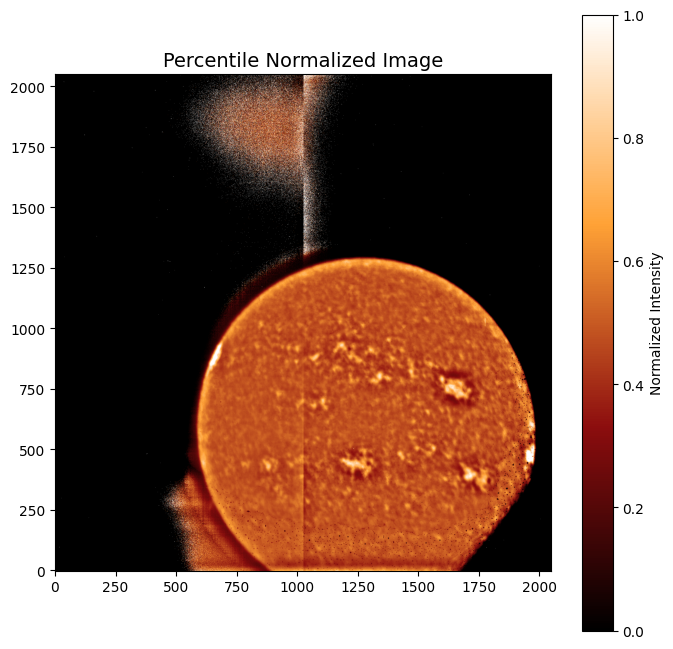

In [37]:
# Applying Percentile Normalization:
P1 = np.percentile(arr_ffc, 1)     # 0
P99 = np.percentile(arr_ffc, 99)   #4658.8745
arr_normalized = (arr_ffc-P1)/(P99-P1)  # Normalized array.
arr_normalized = np.clip(arr_normalized,0,1)  # so that all values stay between 0 and 1
plt.figure(figsize=(8,8))
plt.imshow(arr_normalized, cmap = cmap, origin = 'lower')
plt.colorbar(label='Normalized Intensity')
plt.title('Percentile Normalized Image', fontsize=14)
plt.show()

Now we are going to resolve the problem of high distortion in the western and southern hemisphere. This can be done by removing the off-disk background of the image, this will neglect everything that is outside the solar disk. We will do it by masking.

In [38]:
# Masking the solar disk: 

x = np.arange(0, 2048)
y = np.arange(0, 2048)
X, Y = np.meshgrid(x, y)
radius = 775
x_center = 1320
y_center = 650
distance = np.sqrt((X-x_center)**2+(Y-y_center)**2)
mask = (distance<=radius)

arr_2d_masked = arr_normalized.copy()
print(len(arr_2d_masked[arr_2d_masked != 0]))
arr_2d_masked[~mask] = 0
print(len(arr_2d_masked[arr_2d_masked != 0]))

1741473
1530695


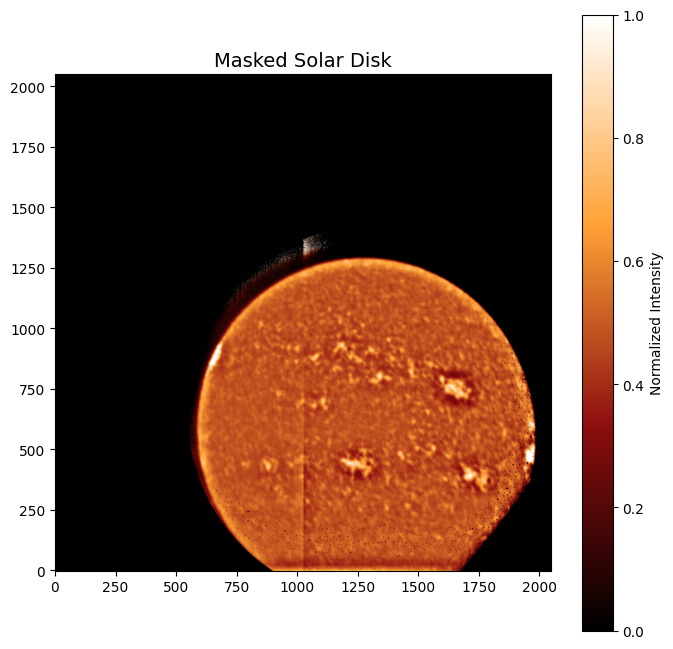

In [39]:
#Image of masked solar disk: 

plt.figure(figsize=(8,8))
norm = suit_norm(arr_2d_masked,'NB03')
plt.imshow(arr_2d_masked, cmap=cmap, origin='lower')
plt.colorbar(label='Normalized Intensity')
plt.title('Masked Solar Disk', fontsize=14)
plt.show()

## Detecting Active Regions using Otsu Thresholding

We now apply Otsu thresholding to the masked, normalized solar disk image to isolate the active regions. Otsu's method automatically finds the optimal threshold by minimizing intra-class variance. We apply it only within the solar disk mask to avoid background pixels from skewing the threshold. But, before we apply thresholding to the image let us take a look at the histogram of the array that we have now after appling ffc, normalization and masking to enhance our understanding of the image. 

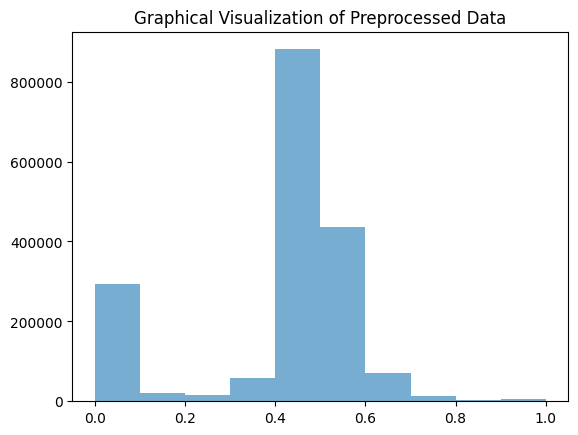

In [40]:
sun_pixels_only = arr_2d_masked[mask]   # it is masked version of arr_2d_masked
plt.hist(sun_pixels_only, alpha=0.6)
plt.title('Graphical Visualization of Preprocessed Data')
plt.show()

We can see from the above graph that it has a peak at  nearly 0 and 0.1. The reason for this peak it that our masking is not masking the solar disk perfectly. Some off disk background is still in the masked image. This will be problematic for our Otsu thresholding as the algoriithm searches for two peaks and assigns threshold in between those peaks in a valley. This will generate an erroneous image. So, we will have to reove that region of the graph before apply thresholding. 

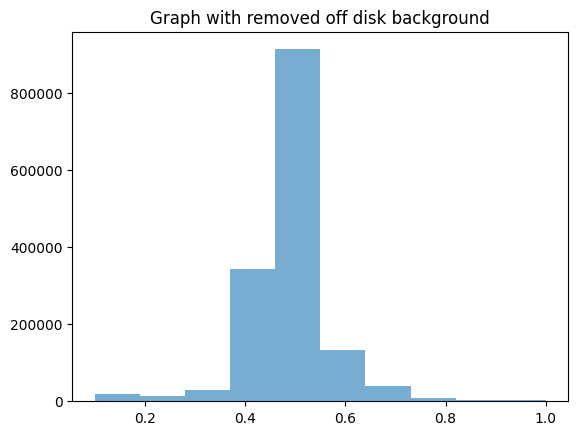

In [41]:
# Fixing the off disk background in the masked image: 
sun_pixels_filtered = sun_pixels_only[sun_pixels_only>0.1]
plt.hist(sun_pixels_filtered, alpha=0.6)
plt.title('Graph with removed off disk background')
plt.show()

Now, as we can see that the older peak is removed but this has created a new problem for Otsu's algorithm. It is an algorithm whih works in a bimodal distributed data which translates to the presence of 2 peaks in the data. But in our data we can see that we have only 1 peak after preprocessing the raw data. This means that Otsu's algorithm here will not do accurate thresholding.

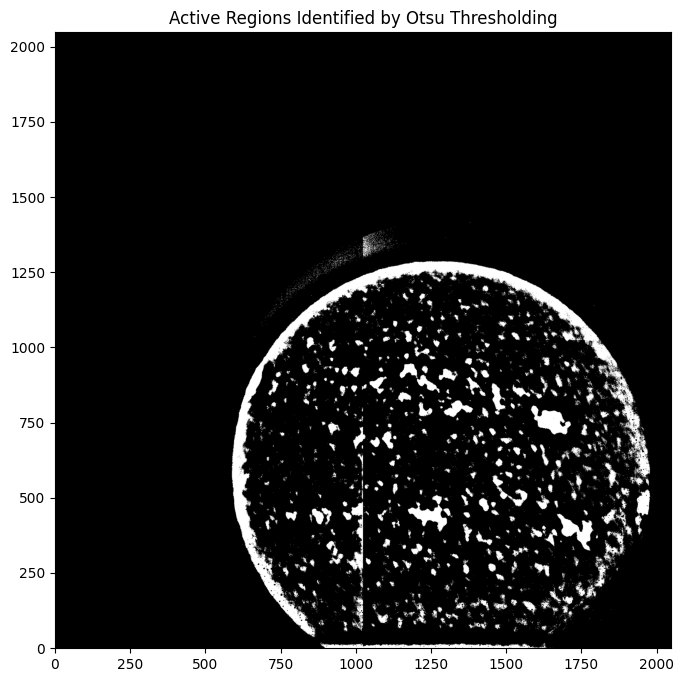

In [42]:
sun_pixels_only = arr_2d_masked[mask]

threshold_value = threshold_otsu(sun_pixels_filtered)   #threshold value: 0.5341811
active_region_mask = (arr_2d_masked>threshold_value) & mask   

plt.figure(figsize=(8,8))
plt.imshow(active_region_mask, cmap=cmap,origin='lower')
plt.title('Active Regions Identified by Otsu Thresholding')
plt.show()

## Observations: 

1. The image generated using Otsu's Algorithm identifies both active regions and solar limb (the circular shell along the perimeter of the solar disk) along with some other patches on the solar disk as active region. 
2. The artifacts in the image are also identified as active regions. This is due to the reason that Otsu's algorithm uses intensity distribution only to classify a region as active or quiet. This is a limitation of this method. 
3. The active regions identified in this image are occupying an area which is much larger than that occupied by active regions. Typically, active regions occupy at most 20% of sun's area and that too when the solar cycle is strong, the current Solar Cycle (SC25) to which our image belongs is a relatively weaker cycle and hence an area this large occupied by active regions is a serious concern.

## Applying Morphological Operations

[np.float64(95884.0), np.float64(7262.0), np.float64(6441.0), np.float64(5717.0), np.float64(5028.0), np.float64(4353.0), np.float64(3376.0), np.float64(2702.0), np.float64(2480.0), np.float64(2135.0), np.float64(2036.0), np.float64(1653.0), np.float64(1627.0), np.float64(1449.0), np.float64(1362.0), np.float64(1320.0), np.float64(1285.0), np.float64(1265.0), np.float64(1225.0), np.float64(1209.0), np.float64(1139.0), np.float64(1066.0), np.float64(1010.0), np.float64(1009.0), np.float64(1006.0), np.float64(981.0), np.float64(914.0), np.float64(907.0), np.float64(897.0), np.float64(862.0), np.float64(861.0), np.float64(848.0), np.float64(833.0), np.float64(807.0), np.float64(792.0), np.float64(792.0), np.float64(787.0), np.float64(781.0), np.float64(768.0), np.float64(753.0), np.float64(733.0), np.float64(712.0), np.float64(701.0), np.float64(673.0), np.float64(665.0), np.float64(660.0), np.float64(659.0), np.float64(656.0), np.float64(642.0), np.float64(632.0), np.float64(632.0), np.f

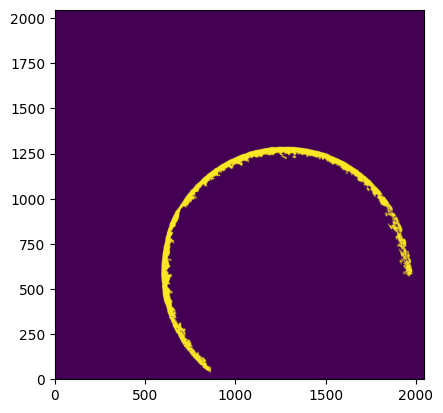

In [43]:
# We will now label the active_region_mask: 

labeled = label(active_region_mask)
labeled_regions = regionprops(labeled)
lst = []                                # We will store in list the areas of labelled regions in descending order to identify limb. 
for i in range(0,len(labeled_regions)):
    lst.append(labeled_regions[i].area)
lst.sort(reverse= True)
print(lst)

for i in range(0, len(labeled_regions)):
    if (labeled_regions[i].area == 95884):
        print(labeled_regions[i].label)
print( labeled_regions[45].label)
test_label = (labeled == 45)            # Verifying if the label found corresponds to the limb or not. 
plt.imshow(test_label, origin='lower')
plt.show()

We can see that we have successfully identified the solar limb label. Now we need to remove this limb an in order to do that we have to create a threshold value above which the area will be excluded. 

In [44]:
print(type(labeled))
print(labeled.dtype)
print(type(labeled_regions))
print(type(test_label))
print(test_label.dtype)
print(labeled_regions[0])

<class 'numpy.ndarray'>
int32
<class 'list'>
<class 'numpy.ndarray'>
bool
<RegionProperties: label=1, bbox=(0, 882, 17, 1595)>


List of labels having area higher than threshold: [45]


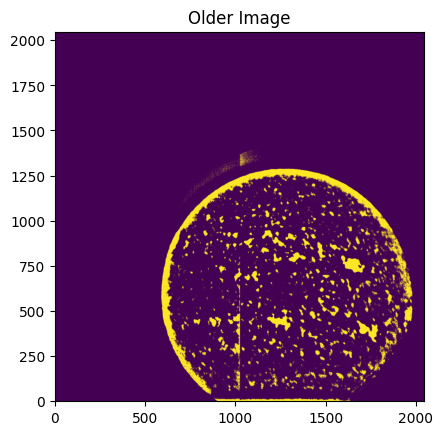

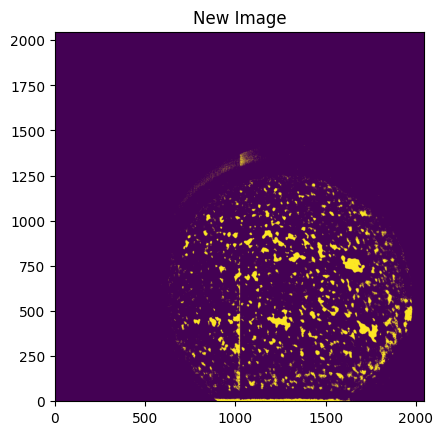

In [45]:
max_threshold_area = 10000   
# I have kept a margin of around 2500 from the second largest value so that any updations in the mask values can be accomodated by area.

bad_labels = []
for i in range(0, len(labeled_regions)):
    if (labeled_regions[i].area >= max_threshold_area):
        bad_labels.append(labeled_regions[i].label)
print(f'List of labels having area higher than threshold: {bad_labels}')

updated_labels = np.isin(labeled, bad_labels)

solar_limb_removed = (active_region_mask) & (~updated_labels)
plt.imshow(active_region_mask, origin='lower')
plt.title('Older Image')
plt.show()
plt.imshow(solar_limb_removed, origin='lower')
plt.title('New Image')
plt.show()

We can see that solar limb has been successfully removed from the image. 



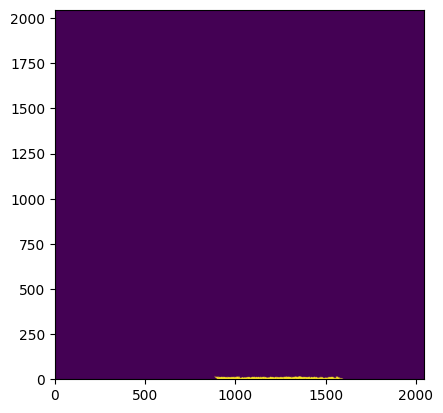

[ 0  0  0 ... 15 15 16]
[ 898  899  900 ...  889 1018  882]


In [46]:
labeled_2 = label(solar_limb_removed)
labeled_2_regions = regionprops(labeled_2)
lst2 = []
for i in range(0, len(labeled_2_regions)):
               lst2.append(labeled_2_regions[i].area)
lst2.sort(reverse=True)
p = 0
for i in range(0, len(labeled_2_regions)):
        if (labeled_2_regions[i].area == 7262   ):
                p = labeled_2_regions[i].label
test_label_2 = (labeled_2 == p)
plt.imshow(test_label_2, origin='lower')
plt.show()
rows, cols = np.where(labeled_2 == p)
print(rows)
print(cols)

### Diagnosis: Mask-Boundary Leakage Blob (Bottom Edge)

After removing the solar limb ring, connected component analysis (`label`, `regionprops`) was reapplied to `solar_limb_removed`. This revealed a second large component — label 1 — with an area of 7,262 pixels, distinctly separated from the remaining smaller components (active region candidates).

To diagnose this component, its pixel coordinates were extracted using `np.where(labeled_2 == p)` (where `p = 1`) and visualized. The resulting plot shows this blob is concentrated along the bottom edge of the disk mask (y ≈ 0–50, x ≈ 900–1500), rather than being distributed across the solar disk like genuine active regions.

This spatial pattern is consistent with the same root cause as the limb ring: since the solar disk is significantly off-centered (`x_center=1320, y_center=650`), the circular mask boundary does not align uniformly with the image edges. As a result, the mask intersects regions of background/edge pixels asymmetrically, causing leakage that survives Otsu thresholding as a spurious "active region" candidate — purely a geometric artifact of the off-centered mask, not real solar physics.

This blob will therefore be removed using the same method applied to the limb ring: masking out all pixels where `labeled_2 == p`.

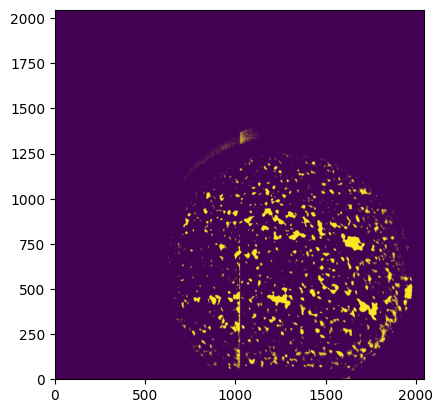

In [47]:
hor_blob_mask = (labeled_2==p)  #masking the horizontal blob that is to be removed.

hor_blob_removed = (solar_limb_removed) & (~hor_blob_mask)  # creating a new array which doesn.t have the horizontal blob and converting it to a image.
plt.imshow(hor_blob_removed, origin='lower')
plt.show()

We have successfully removed the horizontal blob after verifying it. 

[np.float64(7262.0), np.float64(6441.0), np.float64(5717.0), np.float64(5028.0), np.float64(4353.0), np.float64(3376.0), np.float64(2702.0), np.float64(2480.0), np.float64(2135.0), np.float64(2036.0), np.float64(1653.0), np.float64(1627.0), np.float64(1449.0), np.float64(1362.0), np.float64(1320.0), np.float64(1285.0), np.float64(1265.0), np.float64(1225.0), np.float64(1209.0), np.float64(1139.0), np.float64(1066.0), np.float64(1010.0), np.float64(1009.0), np.float64(1006.0), np.float64(981.0), np.float64(914.0), np.float64(907.0), np.float64(897.0), np.float64(862.0), np.float64(861.0), np.float64(848.0), np.float64(833.0), np.float64(807.0), np.float64(792.0), np.float64(792.0), np.float64(787.0), np.float64(781.0), np.float64(768.0), np.float64(753.0), np.float64(733.0), np.float64(712.0), np.float64(701.0), np.float64(673.0), np.float64(665.0), np.float64(660.0), np.float64(659.0), np.float64(656.0), np.float64(642.0), np.float64(632.0), np.float64(632.0), np.float64(623.0), np.flo

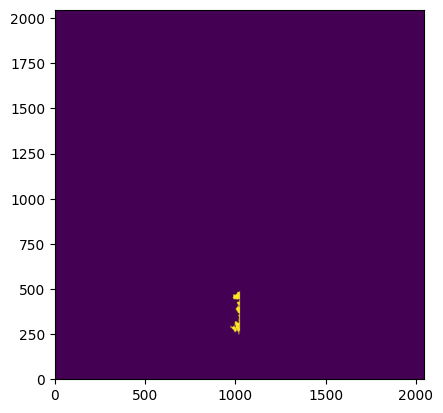

In [48]:
lst2 = []
for i in range(0, len(labeled_2_regions)):
               lst2.append(labeled_2_regions[i].area)
lst2.sort(reverse=True)
print(lst2)
p = 0
for i in range(0, len(labeled_2_regions)):
        if (labeled_2_regions[i].area == 4353):
                p = labeled_2_regions[i].label
                print(labeled_2_regions[i].area)
                print(labeled_2_regions[i].bbox)
test_label_2 = (labeled_2 == p)
plt.imshow(test_label_2, origin='lower')
plt.show()

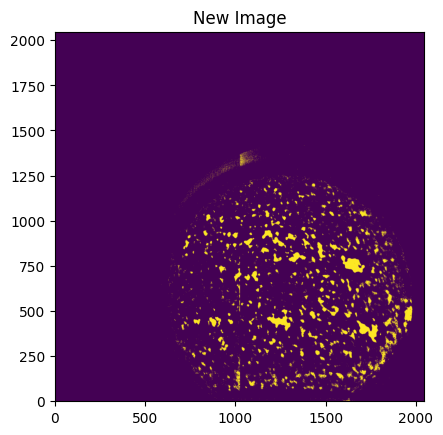

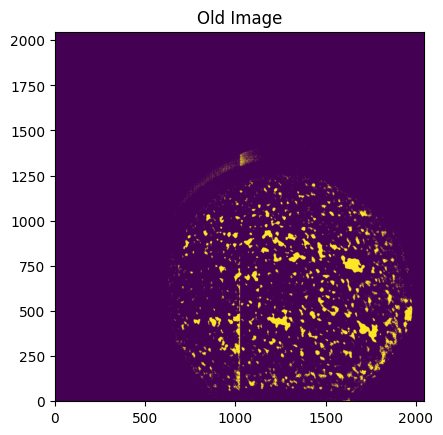

In [49]:
ver_blob_mask = (labeled_2 == p)
ver_blob_removed = (hor_blob_removed) & (~ver_blob_mask)
plt.imshow(ver_blob_removed, origin='lower')
plt.title('New Image')
plt.show()
plt.imshow(hor_blob_removed, origin='lower')
plt.title('Old Image')
plt.show()

### Diagnosis & Removal: Vertical Stripe Artifact (Bad Column)

After removing the horizontal mask-boundary blob, connected component analysis on the remaining mask revealed another distinct large component — label `p`, area 4,353 pixels — with a bounding box of `(246, 970, 487, 1024)`. Unlike the limb ring and horizontal blob (both edge-of-mask artifacts caused by the off-centered disk), this component sits well inside the solar disk, at roughly the disk's mid-region.

Its bounding box gives a height of ~241 pixels and a width of ~54 pixels — a height-to-width ratio of roughly 4.5, indicating an elongated, stripe-like shape rather than the compact, irregular shape typical of genuine active regions.

To confirm this was an artifact rather than real solar signal, the same region was inspected directly in the raw (unprocessed) intensity image. A faint but distinctly straight vertical line is visible at the same x-position, cutting through the disk regardless of the solar features it crosses — a hallmark of an instrumental defect (commonly a "bad column," caused by a column of detector pixels with anomalous response) rather than a physical solar feature, which would have an irregular, organic boundary.

Based on this, the component was removed using the same label-and-subtract approach applied to prior artifacts:

```python
ver_blob_mask = (labeled_2 == p)
ver_blob_removed = (hor_blob_removed) & (~ver_blob_mask)
```

A before/after visual comparison (zoomed to the stripe's bounding box) confirmed the dense core of the stripe was removed, with active-region pixels in the surrounding area retaining their natural, irregular boundaries — i.e., no real solar signal was inadvertently removed. A faint remnant of the stripe may still be visible, likely corresponding to lower-intensity edge pixels of the same defect that fell just below the area/connectivity threshold used here; this can be addressed separately if needed (e.g., via erosion) but does not significantly affect the active region analysis.

False
True


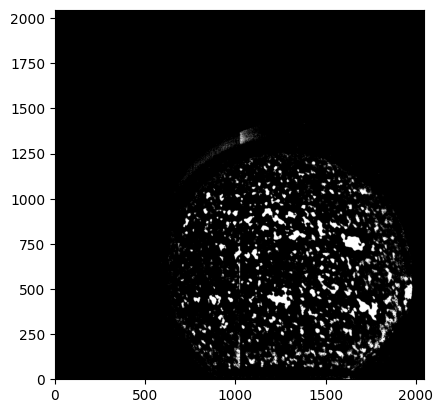

In [50]:
plt.imshow(ver_blob_removed,cmap=cmap,  origin='lower')
print(np.min(ver_blob_removed))
print(np.max(ver_blob_removed))
plt.show()

In [51]:
# Removing off disk blob: 
x = 1000
y = 1300
dist = np.sqrt((x-1320)**2 + (y-650)**2)
print(dist)

print(active_region_mask[1250:1400,950:1150])
print(np.where(active_region_mask[1250:1400, 950:1150]))

print(labeled_2[1250, 1060])
print(labeled_2[1250,1061])
print(labeled_2[1371,1106])



724.4998274671982
[[False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
(array([  0,   0,   0, ..., 141, 143, 144], shape=(3077,)), array([110, 111, 112, ..., 156, 168, 165], shape=(3077,)))
0
0
6921


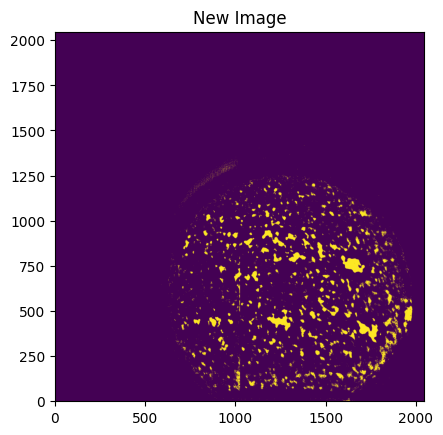

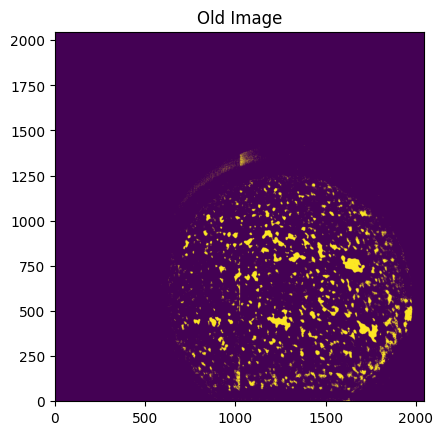

In [52]:
rows, cols = np.where(active_region_mask[1290:1400, 1010:1150])

off_disk_masked = np.zeros(active_region_mask.shape, dtype=bool)
off_disk_masked[1290:1400, 1010:1150] = True
off_disk_removed = (ver_blob_removed) & (~off_disk_masked)
plt.imshow(off_disk_removed, origin='lower')
plt.title('New Image')
plt.show()
plt.imshow(ver_blob_removed, origin='lower')
plt.title('Old Image')
plt.show()

In [53]:
print(ver_blob_removed.sum())
print(off_disk_removed.sum())
print((ver_blob_removed & off_disk_masked).sum())

141902
140322
1580


### Diagnosis & Removal: Off-Disk Mask Leakage (Stray Light / Background Cluster)

After removing the vertical stripe, a diffuse, irregularly-shaped structure remained visible above the sun's true visible limb, near (x≈950–1150, y≈1250–1400). Although this region lies outside the sun's actual photospheric edge, it was found to be inside the circular disk mask (`radius=775`, `x_center=1320`, `y_center=650`) — a representative point in this structure measured a distance of ~724.5 pixels from the mask center, comfortably within the 775-pixel radius cutoff.

This confirms the structure is a consequence of the same root cause as earlier artifacts: because the solar disk is significantly off-centered in the frame, a single fixed circular radius cannot perfectly trace the true limb in every direction. In this direction (upward from center), the mask radius slightly overshoots the true disk edge, allowing background or stray-light pixels to be included as if they were within the solar disk. Since these pixels were bright enough to cross the Otsu threshold in patches, they appear in `active_region_mask`.

Unlike the limb ring, horizontal blob, and vertical stripe — each of which existed as one large, well-defined connected component — this structure was found (via `np.unique` on `labeled_2` over the affected region) to be fragmented across hundreds of small, scattered labels, with no single dominant component to target. A label-based removal approach was therefore not appropriate here.

Instead, a global radius/center adjustment was considered and rejected: shrinking the mask radius uniformly to exclude this artifact was found to cut into genuine solar limb pixels in other directions (bottom-left of the disk), and altering `x_center`, `y_center`, or `radius` retroactively would invalidate the already-validated, previously-documented removal steps performed earlier in this pipeline (limb ring, horizontal blob, vertical stripe), all of which were computed using the original mask parameters.

A targeted, coordinate-based exclusion was used instead. The structure's spatial extent was determined empirically using `np.where()` on slices of `active_region_mask`, iteratively widening the test window until the structure's bright, dense core was fully bounded with margin on all sides. The full diffuse structure included a faint diagonal trail that blended into nearby genuine active-region pixels with no clear separating boundary; rather than risk damaging real signal by chasing this faint trail, only the dense, clearly artifact-like core (bounding box: rows 1290–1400, columns 1010–1150) was targeted for removal, consistent with the same scope-limiting judgment applied to the vertical stripe's faint remnant.

```python
off_disk_masked = np.zeros(active_region_mask.shape, dtype=bool)
off_disk_masked[1290:1400, 1010:1150] = True

off_disk_removed = (ver_blob_removed) & (~off_disk_masked)
```

This removed exactly 1,580 pixels (`ver_blob_removed.sum() - off_disk_removed.sum() = 141902 - 140322 = 1580`, matching `(ver_blob_removed & off_disk_masked).sum() = 1580` exactly), confirming the operation removed precisely the intended pixels with no unintended side effects. Visual comparison confirmed all other active region pixels on the disk remained unchanged between `ver_blob_removed` and `off_disk_removed`.

**Known limitation:** a faint diagonal trail (the lower-intensity tail of this same structure) remains in `off_disk_removed`, along with a faint remnant of the vertical stripe's halo pixels noted earlier. Both were judged too faint and too close to genuine active-region signal to remove without risking damage to real data, and are not expected to materially affect active region detection or counting in this analysis.